In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [41]:
df = pd.read_csv('Salary_Data.csv')
df = df.dropna(subset=['Years of Experience', 'Salary'])
print('Number of features:', len(df.columns))
print('Number of patterns:', len(df))
print('Range of salaries:', df['Salary'].min(), '-', df['Salary'].max())

Number of features: 6
Number of patterns: 6699
Range of salaries: 350.0 - 250000.0


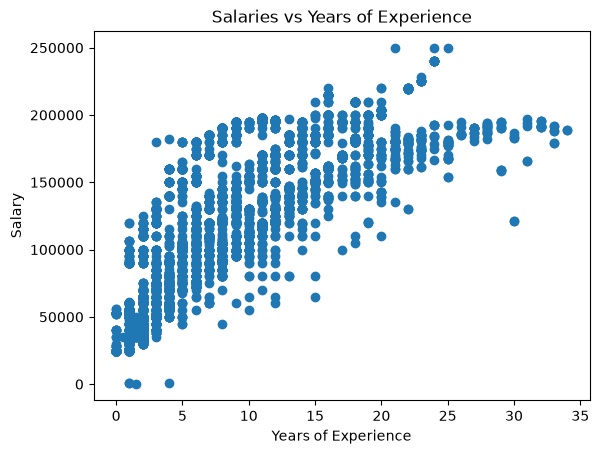

In [43]:
plt.scatter(df['Years of Experience'], df['Salary'])
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Salaries vs Years of Experience')
plt.show()

In [ ]:
os.makedirs('dataset', exist_ok=True)
i = 1
for x in range(10, 100, 10):
    y = 100 - x
    train = df.sample(frac=x/100, random_state=42)
    test = df.drop(train.index)
    train.to_csv(f'dataset/set{i}_{x}_train.csv', index=False)
    test.to_csv(f'dataset/set{i}_{y}_test.csv', index=False)
    print(f'Split {x}:{y} -> Train: set{i}_{x}_train.csv ({len(train)}), Test: set{i}_{y}_test.csv ({len(test)})')
    i += 1

Split 10:90 -> Train: set1_10_train.csv (670), Test: set1_90_test.csv (6029)
Split 20:80 -> Train: set2_20_train.csv (1340), Test: set2_80_test.csv (5359)
Split 30:70 -> Train: set3_30_train.csv (2010), Test: set3_70_test.csv (4689)
Split 40:60 -> Train: set4_40_train.csv (2680), Test: set4_60_test.csv (4019)
Split 50:50 -> Train: set5_50_train.csv (3350), Test: set5_50_test.csv (3349)
Split 60:40 -> Train: set6_60_train.csv (4019), Test: set6_40_test.csv (2680)
Split 70:30 -> Train: set7_70_train.csv (4689), Test: set7_30_test.csv (2010)
Split 80:20 -> Train: set8_80_train.csv (5359), Test: set8_20_test.csv (1340)
Split 90:10 -> Train: set9_90_train.csv (6029), Test: set9_10_test.csv (670)


In [45]:
x_exp = df['Years of Experience'].values
y_sal = df['Salary'].values
n = len(df)
mean_exp = np.mean(x_exp)
mean_sal = np.mean(y_sal)
var_exp = np.sum((x_exp - mean_exp)**2) / (n - 1)
std_exp = np.sqrt(var_exp)
var_sal = np.sum((y_sal - mean_sal)**2) / (n - 1)
std_sal = np.sqrt(var_sal)
cov_val = np.sum((x_exp - mean_exp) * (y_sal - mean_sal)) / (n - 1)
print('Years of Experience Standard Deviation:', std_exp)
print('Years of Experience Variance:', var_exp)
print('Salary Standard Deviation:', std_sal)
print('Salary Variance:', var_sal)
print('Covariance between Salaries and Years of Experience:', cov_val)

Years of Experience Standard Deviation: 6.059853418262609
Years of Experience Variance: 36.72182345082902
Salary Standard Deviation: 52786.18391068298
Salary Variance: 2786381211.8524466
Covariance between Salaries and Years of Experience: 258770.18302826918


In [46]:
x = df['Years of Experience'].values
y = df['Salary'].values
mean_x = np.mean(x)
mean_y = np.mean(y)
num = np.sum((x - mean_x) * (y - mean_y))
den = np.sqrt(np.sum((x - mean_x)**2) * np.sum((y - mean_y)**2))
r = num / den
print("Pearson's correlation coefficient:", r)
if r > 0:
    print('Result indicates a strong positive linear relationship between years of experience and salary.')
elif r < 0:
    print('Result indicates a negative linear relationship.')
else:
    print('Result indicates no linear correlation.')

Pearson's correlation coefficient: 0.8089689398558261
Result indicates a strong positive linear relationship between years of experience and salary.


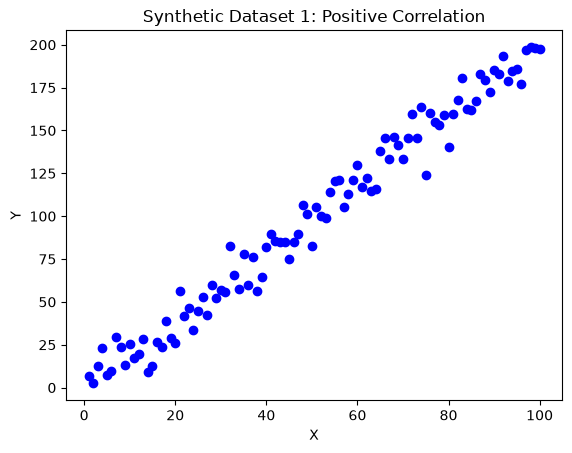

Dataset 1 Covariance: 1695.05993266837
Dataset 1 Pearson correlation coefficient: 0.9881575050985862
Interpretation: The positive value close to 1 indicates a strong positive linear relationship between X and Y.


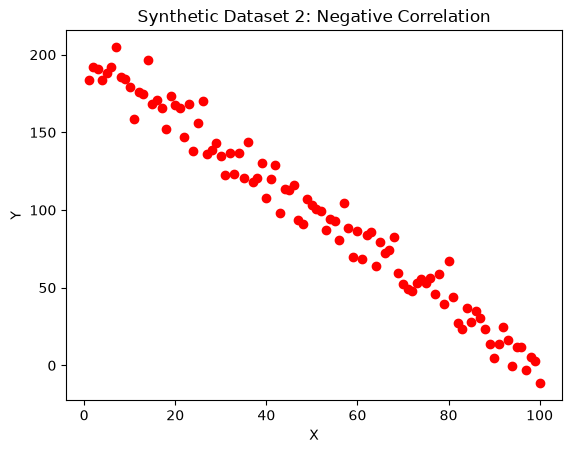

Dataset 2 Covariance: -1681.618518559455
Dataset 2 Pearson correlation coefficient: -0.9867344715359684
Interpretation: The negative value close to -1 indicates a strong negative linear relationship between X and Y.


In [47]:
np.random.seed(42)
x_pos = np.linspace(1, 100, 100)
y_pos = 2 * x_pos + np.random.normal(0, 10, 100)
mean_xp = np.mean(x_pos)
mean_yp = np.mean(y_pos)
cov_pos = np.sum((x_pos - mean_xp) * (y_pos - mean_yp)) / (len(x_pos) - 1)
r_pos = np.sum((x_pos - mean_xp) * (y_pos - mean_yp)) / (np.sqrt(np.sum((x_pos - mean_xp)**2)) * np.sqrt(np.sum((y_pos - mean_yp)**2)))
plt.scatter(x_pos, y_pos, color='blue')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Synthetic Dataset 1: Positive Correlation')
plt.show()
print('Dataset 1 Covariance:', cov_pos)
print('Dataset 1 Pearson correlation coefficient:', r_pos)
print('Interpretation: The positive value close to 1 indicates a strong positive linear relationship between X and Y.')

x_neg = np.linspace(1, 100, 100)
y_neg = -2 * x_neg + 200 + np.random.normal(0, 10, 100)
mean_xn = np.mean(x_neg)
mean_yn = np.mean(y_neg)
cov_neg = np.sum((x_neg - mean_xn) * (y_neg - mean_yn)) / (len(x_neg) - 1)
r_neg = np.sum((x_neg - mean_xn) * (y_neg - mean_yn)) / (np.sqrt(np.sum((x_neg - mean_xn)**2)) * np.sqrt(np.sum((y_neg - mean_yn)**2)))
plt.scatter(x_neg, y_neg, color='red')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Synthetic Dataset 2: Negative Correlation')
plt.show()
print('Dataset 2 Covariance:', cov_neg)
print('Dataset 2 Pearson correlation coefficient:', r_neg)
print('Interpretation: The negative value close to -1 indicates a strong negative linear relationship between X and Y.')

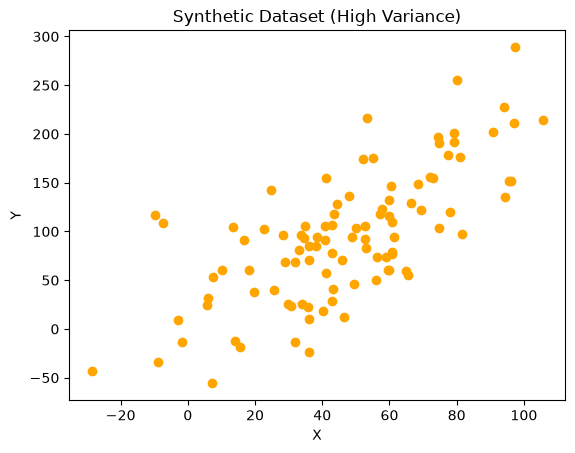

High Variance Dataset X Variance: 742.2929042671442
High Variance Dataset Y Variance: 4533.957702687428
High Variance Dataset Covariance: 1307.354519276032
High Variance Dataset Pearson correlation coefficient: 0.7126347334674836
Interpretation: High variance in data points results in a larger spread from the mean, producing large variance and covariance values.


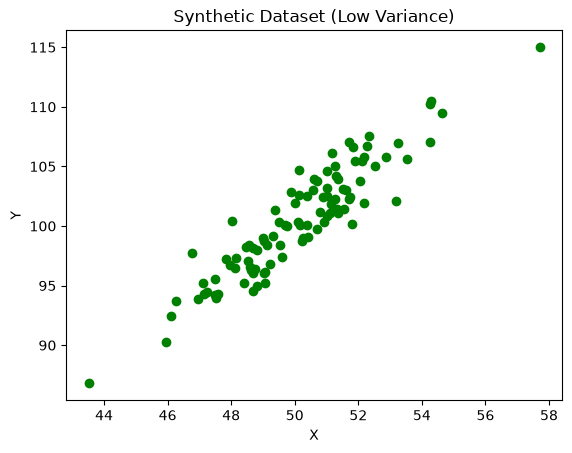

Low Variance Dataset X Variance: 4.702677476154969
Low Variance Dataset Y Variance: 21.933277758173727
Low Variance Dataset Covariance: 9.404361601201932
Low Variance Dataset Pearson correlation coefficient: 0.9259871352278111
Interpretation: Low variance dataset points are tightly clustered around the mean, resulting in small variance and covariance values.


: 

In [ ]:
np.random.seed(42)
x_high = np.random.normal(50, 30, 100)
y_high = 2 * x_high + np.random.normal(0, 50, 100)
mean_xh = np.mean(x_high)
mean_yh = np.mean(y_high)
var_xh = np.sum((x_high - mean_xh)**2) / (len(x_high) - 1)
var_yh = np.sum((y_high - mean_yh)**2) / (len(y_high) - 1)
cov_high = np.sum((x_high - mean_xh) * (y_high - mean_yh)) / (len(x_high) - 1)
r_high = np.sum((x_high - mean_xh) * (y_high - mean_yh)) / (np.sqrt(np.sum((x_high - mean_xh)**2)) * np.sqrt(np.sum((y_high - mean_yh)**2)))
plt.scatter(x_high, y_high, color='orange')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Synthetic Dataset (High Variance)')
plt.show()
print('High Variance Dataset X Variance:', var_xh)
print('High Variance Dataset Y Variance:', var_yh)
print('High Variance Dataset Covariance:', cov_high)
print('High Variance Dataset Pearson correlation coefficient:', r_high)
print('Interpretation: High variance in data points results in a larger spread from the mean, producing large variance and covariance values.')

x_low = np.random.normal(50, 2, 100)
y_low = 2 * x_low + np.random.normal(0, 2, 100)
mean_xl = np.mean(x_low)
mean_yl = np.mean(y_low)
var_xl = np.sum((x_low - mean_xl)**2) / (len(x_low) - 1)
var_yl = np.sum((y_low - mean_yl)**2) / (len(y_low) - 1)
cov_low = np.sum((x_low - mean_xl) * (y_low - mean_yl)) / (len(x_low) - 1)
r_low = np.sum((x_low - mean_xl) * (y_low - mean_yl)) / (np.sqrt(np.sum((x_low - mean_xl)**2)) * np.sqrt(np.sum((y_low - mean_yl)**2)))
plt.scatter(x_low, y_low, color='green')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Synthetic Dataset (Low Variance)')
plt.show()
print('Low Variance Dataset X Variance:', var_xl)
print('Low Variance Dataset Y Variance:', var_yl)
print('Low Variance Dataset Covariance:', cov_low)
print('Low Variance Dataset Pearson correlation coefficient:', r_low)
print('Interpretation: Low variance dataset points are tightly clustered around the mean, resulting in small variance and covariance values.')